Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Stage-1 model...
Loading Stage-2 model...


Saving Bacterial Pneumonia (1149).jpg to Bacterial Pneumonia (1149).jpg
Uploaded: Bacterial Pneumonia (1149).jpg
Stage 1: Pneumonia (100.00%)
Stage 2 results: [[0.9815978 0.0184022]]
Final Diagnosis: Bacterial Pneumonia (98.16%)


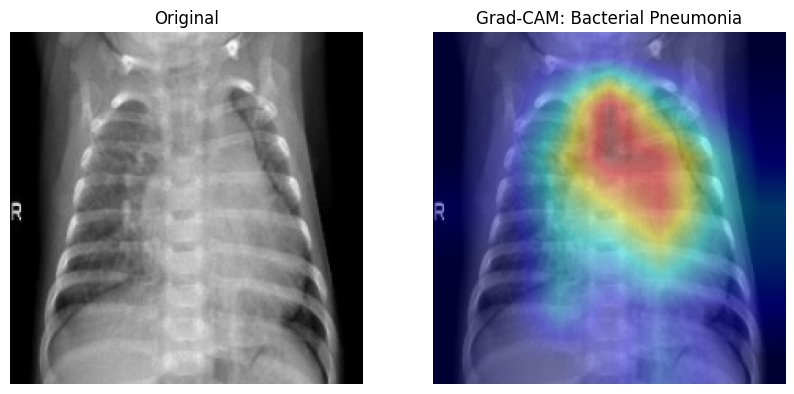


Generated Caption:
 Diagnosis: Bacterial Pneumonia (confidence 98.2%). Radiographic findings suggest bacterial infection.

Pipeline finished.


In [10]:

!pip install -q transformers ftfy opencv-python-headless

import os, time, random
from google.colab import files
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess


from google.colab import drive
drive.mount('/content/drive')

# ---------------------------
# CONFIG
DRIVE_BASE = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(DRIVE_BASE, "model")
HEATMAP_DIR = os.path.join(DRIVE_BASE, "heatmap")
os.makedirs(HEATMAP_DIR, exist_ok=True)

STAGE1_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage1_norm_vs_pneu_fixed.keras")
STAGE2_MODEL_PATH = os.path.join(MODEL_DIR, "New_efficientnetb0_stage2_bac_vs_vir.keras")

STAGE1_CLASSES = ["Normal", "Pneumonia"]
STAGE2_CLASSES = ["Bacterial Pneumonia", "Viral Pneumonia"]

IMG_SIZE = (224, 224)
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# ---------------------------
# LOAD MODELS
print("Loading Stage-1 model...")
stage1_model = tf.keras.models.load_model(STAGE1_MODEL_PATH)
print("Loading Stage-2 model...")
stage2_model = tf.keras.models.load_model(STAGE2_MODEL_PATH)



# ---------------------------
# UPLOAD IMAGE
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit("No file uploaded.")
filename = list(uploaded.keys())[0]
image_path = os.path.join("/content", filename)
print("Uploaded:", filename)


# ---------------------------
# PREPROCESS
def preprocess_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    return effnet_preprocess(x)

def generate_gradcam(model, img_array, layer_name=None):

    if layer_name is None:
        layer_name = find_last_conv_layer(model)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.outputs[0]]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array, training=False)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= (tf.reduce_max(heatmap)+1e-8)

    return heatmap.numpy()

def overlay_heatmap(original_path, heatmap):
    orig_bgr = cv2.imread(original_path)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (orig_rgb.shape[1], orig_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(orig_rgb, 0.6, heatmap_color, 0.4, 0)
    return superimposed

# ---------------------------
# CAPTION
def generate_caption(label, conf):
    if label == "Normal":
        return f"Diagnosis: Normal (confidence {conf:.1f}%). No signs of pneumonia."
    elif "Bacterial" in label:
        return f"Diagnosis: {label} (confidence {conf:.1f}%). Radiographic findings suggest bacterial infection."
    else:
        return f"Diagnosis: {label} (confidence {conf:.1f}%). Radiographic findings suggest viral pneumonia."

# ---------------------------
# RUN STAGE 1
x1 = preprocess_image(image_path)
preds1 = stage1_model.predict(x1, verbose=0)
conf1 = float(np.max(preds1) * 100)
label1 = STAGE1_CLASSES[int(np.argmax(preds1))]
print(f"Stage 1: {label1} ({conf1:.2f}%)")

if label1 == "Normal":
    caption = generate_caption(label1, conf1)
    print("\nFinal Diagnosis:", caption)
else:
    # Stage 2
    x2 = preprocess_image(image_path)
    preds2 = stage2_model.predict(x2, verbose=0)
    conf2 = float(np.max(preds2) * 100)
    label2 = STAGE2_CLASSES[int(np.argmax(preds2))]
    print("Stage 2 results:", preds2)
    print(f"Final Diagnosis: {label2} ({conf2:.2f}%)")

    # Grad-CAM
    heatmap = generate_gradcam(stage2_model, x2)
    overlay = overlay_heatmap(image_path, heatmap)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.imshow(load_img(image_path)); plt.axis('off'); plt.title("Original")
    plt.subplot(1,2,2); plt.imshow(overlay); plt.axis('off'); plt.title(f"Grad-CAM: {label2}")
    plt.show()

    caption = generate_caption(label2, conf2)
    print("\nGenerated Caption:\n", caption)

print("\nPipeline finished.")
